## Webscrapping

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import warnings 

warnings.filterwarnings('ignore')

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

books = soup.find_all("article", class_="product_pod")

In [7]:
data = []
for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.p["class"][1]   # rating is stored as a class name
    data.append({"Title": title, "Price": price, "Rating": rating})

df = pd.DataFrame(data)
df.to_csv('books.csv', index=False)

## EDA

In [8]:
df.shape

(20, 3)

In [9]:
df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   20 non-null     object
 1   Price   20 non-null     object
 2   Rating  20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes


In [11]:
df.describe()

,Title,Price,Rating
count,20,20,20
unique,20,20,5
top,A Light in the Attic,Â£51.77,One
freq,1,1,6


## Data Cleaning

In [12]:
# checking missing values
df.isna().sum()

Title     0
Price     0
Rating    0
dtype: int64

In [13]:
# Remove £ directly inside the column
df["Price"].replace("Â£", "",regex=True, inplace=True)

In [14]:
df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five


In [15]:
df["Price"] = df["Price"].astype(float)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   20 non-null     object 
 1   Price   20 non-null     float64
 2   Rating  20 non-null     object 
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes


In [17]:
df["Rating"].unique()

array(['Three', 'One', 'Four', 'Five', 'Two'], dtype=object)

In [18]:
# Apply mapping
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

# Apply mapping
df["Rating"] = df["Rating"].map(rating_map)

In [19]:
df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   20 non-null     object 
 1   Price   20 non-null     float64
 2   Rating  20 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 612.0+ bytes


## Data Visualization

Text(0, 0.5, 'Number of books')

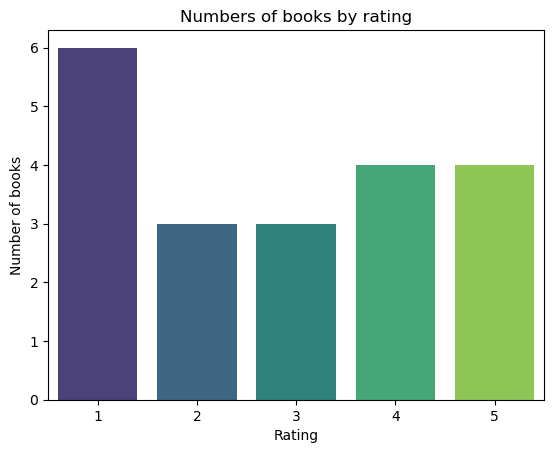

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x = df['Rating'], data=df, palette='viridis')
plt.title("Numbers of books by rating")
plt.ylabel("Number of books")

## Histogram of Book Prices

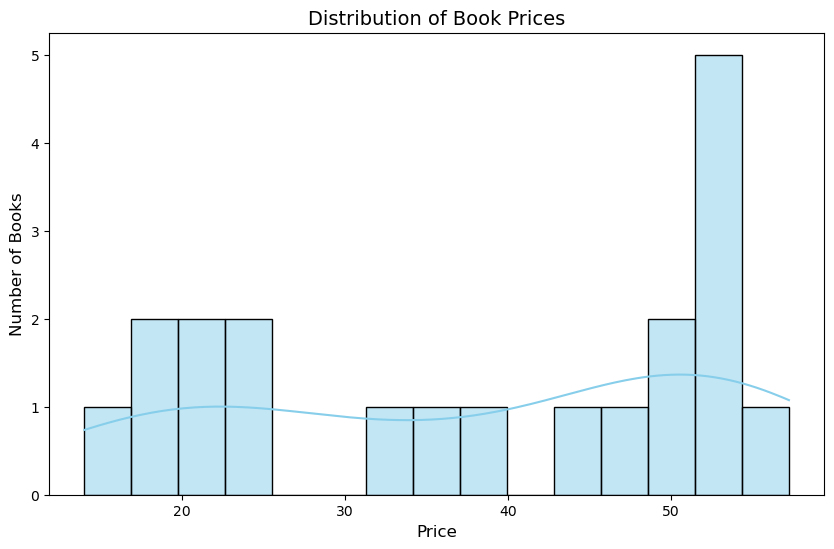

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Book Prices', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)
plt.show()

## Top 10 Books by Price

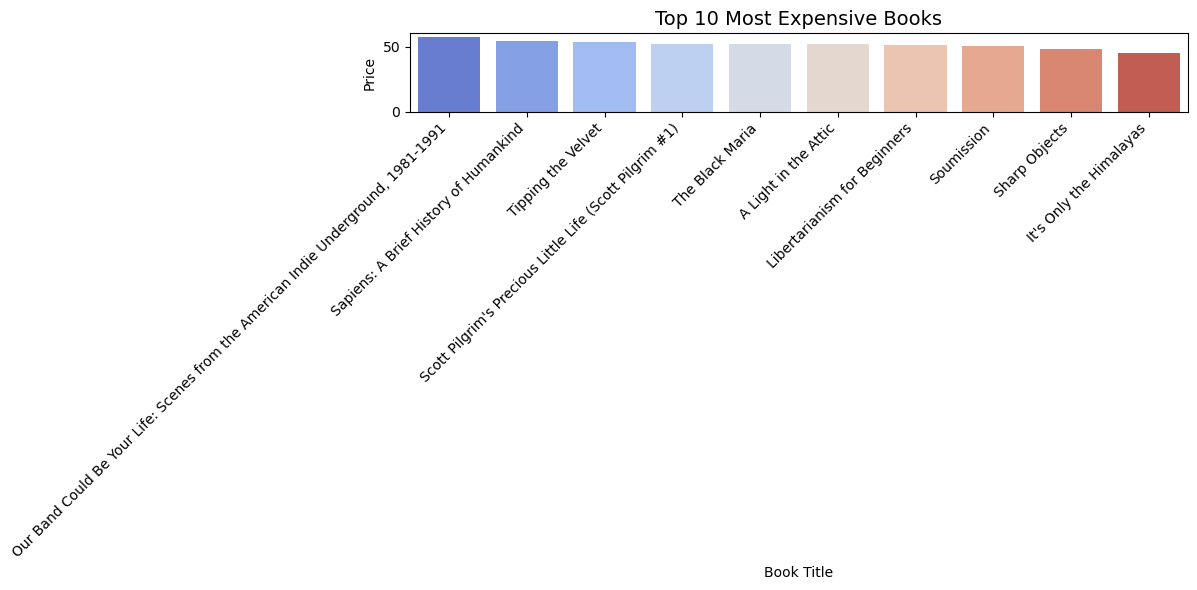

In [28]:
# Get top 10 most expensive books
top_books = df.nlargest(10, 'Price')

plt.figure(figsize=(12, 6))
sns.barplot(x='Title', y='Price', data=top_books, palette='coolwarm')
plt.title('Top 10 Most Expensive Books', fontsize=14)
plt.xlabel('Book Title')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

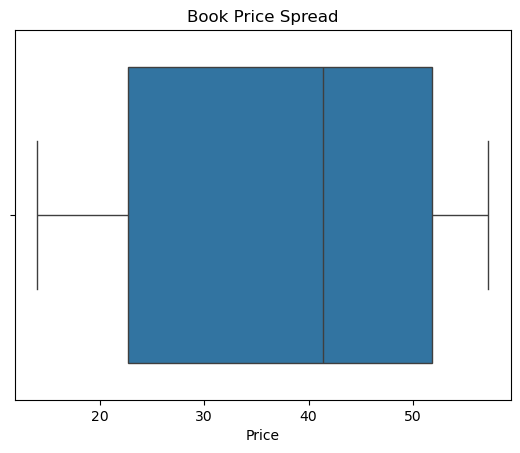

In [30]:
sns.boxplot(x=df["Price"])
plt.title("Book Price Spread")
plt.show()

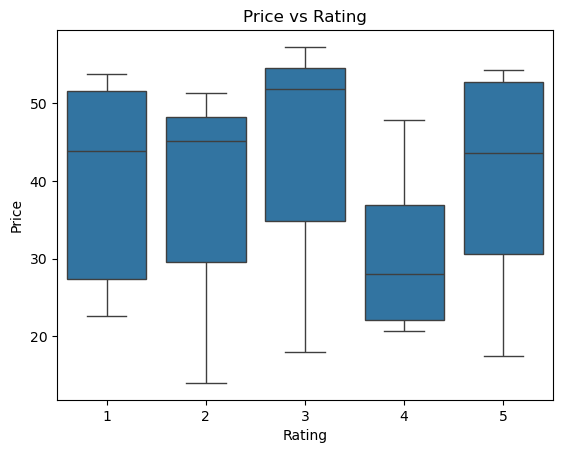

In [118]:
sns.boxplot(x="Rating", y="Price", data=df)
plt.title("Price vs Rating")
plt.show()

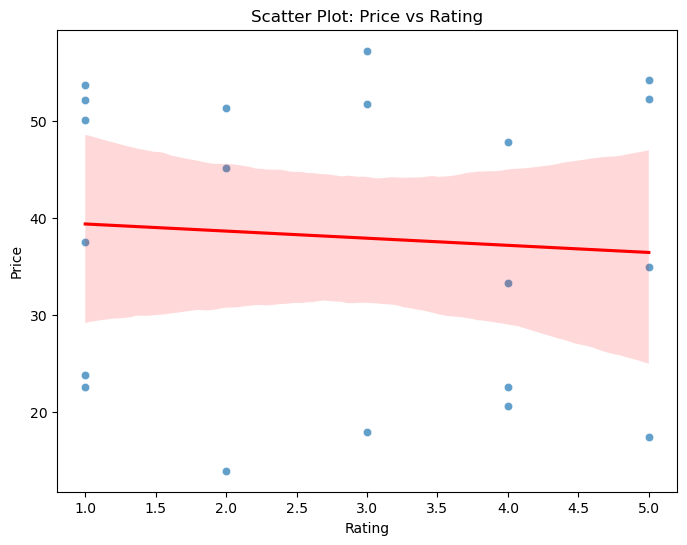

In [31]:
plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(x="Rating", y="Price", data=df, alpha=0.7)

# Add regression/trend line
sns.regplot(x="Rating", y="Price", data=df, scatter=False, color="red")

plt.title("Scatter Plot: Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

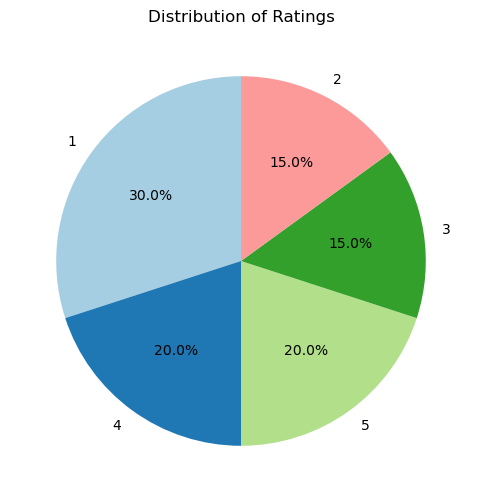

In [32]:
# Count how many items in each rating
rating_counts = df['Rating'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Paired.colors)

plt.title("Distribution of Ratings")
plt.show()

Text(0.5, 1.0, 'Price vs Rating Correlation')

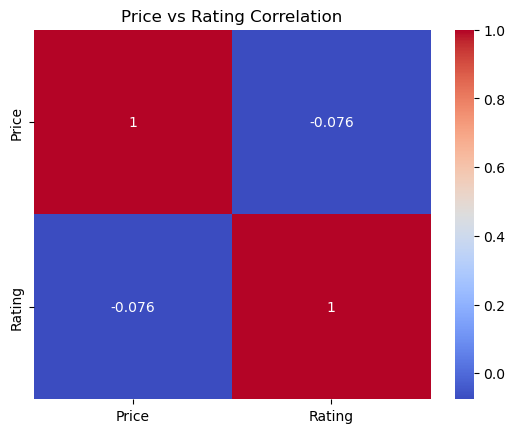

In [33]:
# Correlation between Price and Rating
corr = df[["Price", "Rating"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Price vs Rating Correlation")